In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("spam.csv")
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
df.isna().any()

Category    False
Message     False
dtype: bool

In [4]:
df.shape

(5572, 2)

In [7]:
df.Category.value_counts()

Category
ham     4825
spam     747
Name: count, dtype: int64

## Implementation of Naive Bayes

In [8]:
 from sklearn.model_selection import train_test_split
 X_train, X_test, y_train, y_test = train_test_split(df.Message, df.Category, test_size=0.2, random_state=5)

In [10]:
X_train[2]

"Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's"

# Convert to a word count table by countVectorizer

In [15]:
from sklearn.feature_extraction.text import CountVectorizer
v= CountVectorizer()
X_train_count = v.fit_transform(X_train)
X_test_count = v.transform(X_test)

len(X_train_count.toarray()) #it indicates the unique word count in the whole data set

4457

#### Model Training

In [18]:
from sklearn.naive_bayes import MultinomialNB, GaussianNB # WE will use MultinomialNB for this text classification
model = MultinomialNB()
model.fit(X_train_count, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [19]:
y_pred = model.predict(X_test_count)

### Model Evaluation: precision, recall, f1 score

In [21]:
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

         ham       0.99      1.00      1.00       970
        spam       0.98      0.96      0.97       145

    accuracy                           0.99      1115
   macro avg       0.99      0.98      0.98      1115
weighted avg       0.99      0.99      0.99      1115



### Model evaluation: Confusion Matrix

[[967   6]
 [  3 139]]


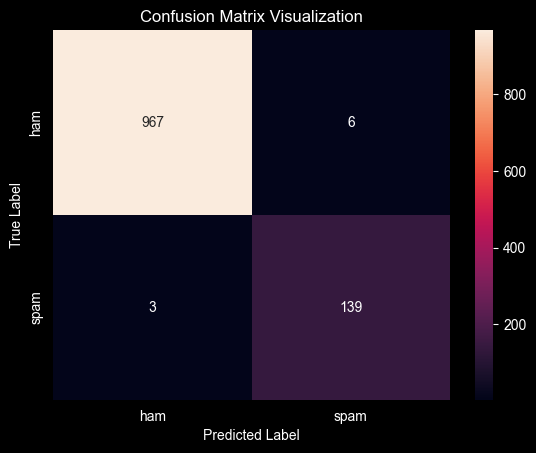

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_pred, y_test)
print(cm)
classes = df.Category.unique()
sns.heatmap(cm, annot=True, xticklabels=classes, yticklabels=classes, fmt='g')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Visualization')
plt.show()

## Prediction test

In [43]:
emails = [
    "Hey Jhon, can we get together to watch footbal match tomorrow?",
    "Upto 20% discount on parking, exclusive offer just for you. Don't miss this reward"
]

emails_count = v.transform(emails)
model.predict(emails_count)

array(['ham', 'spam'], dtype='<U4')

In [44]:
model.predict_proba(emails_count)

array([[9.99971682e-01, 2.83178402e-05],
       [1.41228903e-02, 9.85877110e-01]])

## Using pipeline train the same model

In [45]:
from sklearn.pipeline import Pipeline
pipeline = Pipeline([
    ("count_vectorizer", CountVectorizer()),
    ("nb_classifier", MultinomialNB()),
])
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

         ham       0.99      1.00      1.00       970
        spam       0.98      0.96      0.97       145

    accuracy                           0.99      1115
   macro avg       0.99      0.98      0.98      1115
weighted avg       0.99      0.99      0.99      1115

